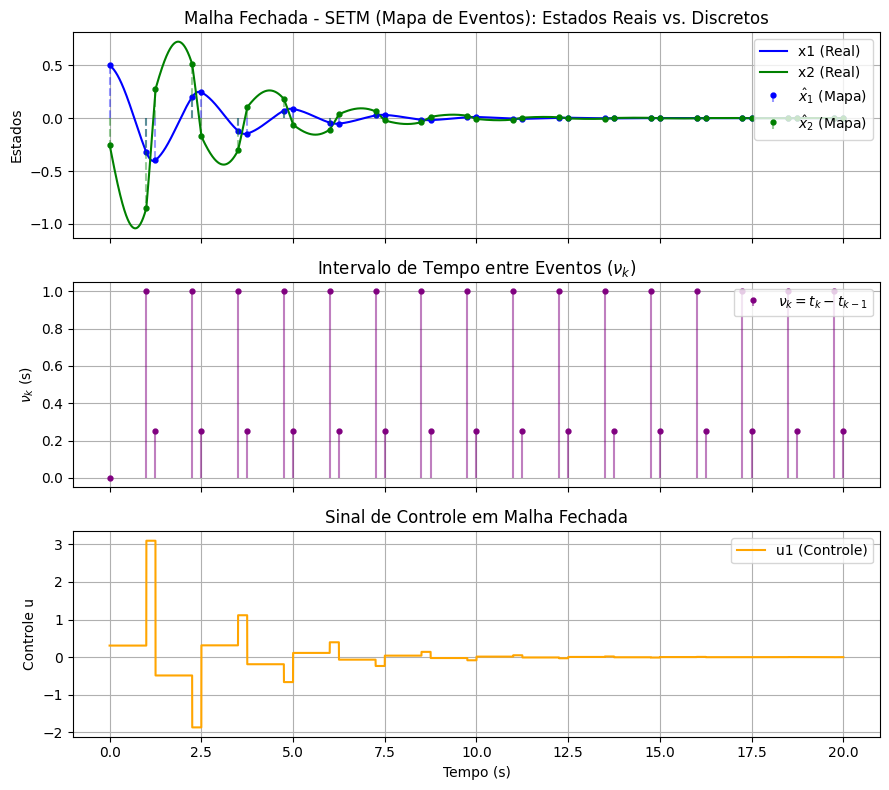

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def load_signal(filepath):
  return np.fromfile(filepath, dtype='float64')


dir_path = 'simulations/lit-system-closed-loop-setm-event-map'

# Carregamento dos vetores de tempo e eventos
time = load_signal(f'{dir_path}/time.bin')
trigger_times = load_signal(f'{dir_path}/trigger_times.bin')

# Carregamento dos estados contínuos e estimados
x1 = load_signal(f'{dir_path}/x1.bin')
x2 = load_signal(f'{dir_path}/x2.bin')
x_est1 = load_signal(f'{dir_path}/x_est1.bin')
x_est2 = load_signal(f'{dir_path}/x_est2.bin')

# Carregamento do sinal de controle
u1 = load_signal(f'{dir_path}/u1.bin')

# Extração dos estados do mapa apenas nos instantes discretos de disparo t_k
idx_trig = np.searchsorted(time, trigger_times)
x_est1_trig = x_est1[idx_trig]
x_est2_trig = x_est2[idx_trig]

# Cálculo do intervalo inter-eventos: \nu_k = t_k - t_{k-1}, com \nu_0 = 0.0
inter_event_times = np.zeros_like(trigger_times)
if len(trigger_times) > 1:
  inter_event_times[1:] = np.diff(trigger_times)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

# 1. Gráfico dos Estados: Contínuos (plot) vs. Discretos do Mapa (stem)
ax1.plot(time, x1, label='x1 (Real)', color='blue', linewidth=1.5)
ax1.plot(time, x2, label='x2 (Real)', color='green', linewidth=1.5)

# Hastes discretas para os estados estimados no mapa (sem linha de base)
marker1, stem1, base1 = ax1.stem(
    trigger_times, x_est1_trig, linefmt='C0--', markerfmt='bo', label=r'$\hat{x}_1$ (Mapa)'
)
plt.setp(stem1, color='blue', alpha=0.4)
plt.setp(marker1, markersize=3.5)
base1.set_visible(False)

marker2, stem2, base2 = ax1.stem(
    trigger_times, x_est2_trig, linefmt='C2--', markerfmt='go', label=r'$\hat{x}_2$ (Mapa)'
)
plt.setp(stem2, color='green', alpha=0.4)
plt.setp(marker2, markersize=3.5)
base2.set_visible(False)

ax1.set_title(
    'Malha Fechada - SETM (Mapa de Eventos): Estados Reais vs. Discretos')
ax1.set_ylabel('Estados')
ax1.legend(loc='upper right')
ax1.grid(True)

# 2. Gráfico do Intervalo de Tempo entre Eventos (\nu_k = t_k - t_{k-1}) (sem linha de base)
marker_ev, stem_ev, base_ev = ax2.stem(
    trigger_times, inter_event_times, linefmt='purple', markerfmt='purple', label=r'$\nu_k = t_k - t_{k-1}$'
)
plt.setp(stem_ev, color='purple', alpha=0.5)
plt.setp(marker_ev, markersize=3.5)
base_ev.set_visible(False)

ax2.set_title(r'Intervalo de Tempo entre Eventos ($\nu_k$)')
ax2.set_ylabel(r'$\nu_k$ (s)')
ax2.legend(loc='upper right')
ax2.grid(True)

# 3. Gráfico do Sinal de Controle (ZOH)
ax3.plot(time, u1, label='u1 (Controle)', color='orange', linewidth=1.5)

ax3.set_title('Sinal de Controle em Malha Fechada')
ax3.set_xlabel('Tempo (s)')
ax3.set_ylabel('Controle u')
ax3.legend(loc='upper right')
ax3.grid(True)

plt.tight_layout()
plt.show()